# Qwen3-8B Q4_K_M Translation Neuron Analysis

Test notebook for Qwen3-8B-Q4_K_M on NVIDIA GB10 (unified memory).
Follows the same experimental flow as the main `translation_neuron.ipynb`:

1. **Setup** - Load model, data, COMET evaluator
2. **Translation Baseline** - Measure translation quality (COMET scores)
3. **Activation Collection** - Gather layer-wise neuron statistics
4. **Logit Lens** - Visualize token predictions across layers
5. **Goal Hijacking** - Compare activation patterns between tasks
6. **Neuron Ablation** - Zero out irregular neurons and measure effect
7. **Activation Steering** - Guide model via directional vectors

## 1. Setup & Environment

In [49]:
import neuroscope
import numpy as np
import sys, os, time, json, warnings
from pathlib import Path
from datasets import load_dataset
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# --- Matplotlib font config: enable CJK & Unicode rendering ---
_cjk_font_dir = '/usr/share/fonts/opentype/noto/'
for _fp in fm.findSystemFonts([_cjk_font_dir]):
    fm.fontManager.addfont(_fp)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Add Test_bench to path for utils/ActivationCollector
sys.path.insert(0, '/workspace/Test_bench')
import utils
from ActivationCollector import ActivationCollector

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['PL_DISABLE_PROGRESS_BAR'] = '1'
os.environ['LIGHTNING_DISABLE_STARTUP_MESSAGE'] = '1'

# --- Route all HuggingFace / torch caches to the host-mounted Data volume ---
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['HF_DATASETS_CACHE'] = '/workspace/Data/huggingface_cache/datasets'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'

print(f"NeuroScope Version: {neuroscope.__version__}")
print(f"CUDA Available: {neuroscope.cuda_available()}")
print(f"CJK Font: {fm.findfont('Noto Sans CJK JP')}")

NeuroScope Version: 1.2.3
CUDA Available: True
CJK Font: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


## 2. Configuration

GB10 has large unified memory — use bigger batch size (64) compared to the original (16).

In [2]:
# ----- Model & Batch Config -----
model_path = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
batch_size = 64   # GB10 unified memory allows larger batches

# ----- Translation Config -----
source_lang = 'zh'
target_lang = 'en'
restriction_level = 'week'

# ----- Output Dir (host-mounted volume — survives container restart) -----
output_dir = Path('/workspace/Data/test_outputs')
output_dir.mkdir(parents=True, exist_ok=True)

print(f'Model: {model_path}')
print(f'Batch size: {batch_size}')
print(f'Output dir: {output_dir}')

Model: /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf
Batch size: 64
Output dir: /workspace/Data/test_outputs


## 3. Load COMET Evaluation Model

In [3]:
from comet import download_model, load_from_checkpoint

comet_model_path = download_model('Unbabel/wmt22-comet-da')
comet_model = load_from_checkpoint(comet_model_path).to('cuda')
print('COMET model loaded.')

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    

COMET model loaded.


## 4. Load Qwen3-8B Q4_K_M Engine

In [4]:
# Qwen3 has a "thinking" mode (<think>...</think>) that consumes hundreds of tokens.
# The KV cache is partitioned: each seq slot gets n_ctx / n_seq_max tokens.
# With n_seq_max=64, n_ctx=8192 → 128 tokens per slot (enough for translation).
# We also disable thinking mode via the nothink template trick (see prompt prep below).
engine = neuroscope.Engine(
    model_path=model_path,
    n_ctx=8192,
    n_gpu_layers=-1,
    n_seq_max=batch_size,
    seed=42,
    temperature=0.7,
    top_p=0.95,
    top_k=40,
    verbose=True,
    disable_flash_attention=False
)

info = engine.model_info
print(f'Model: {info.name}')
print(f'Architecture: {info.architecture}')
print(f'Layers: {info.n_layers}, Hidden: {info.n_embd}, Heads: {info.n_heads}')
print(f'Vocab: {info.n_vocab}, Context: {info.n_ctx}')

[CoreEngine] Loading model: /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf
[CoreEngine] Preparing logit lens resources:
  - Tensor shape: [151936, 4096]
  - Tensor type: q6_K
  - Quantized weights (q6_K) dequantized to FP16
  - FP16 weights allocated on GPU: 1187 MB
  - Logit lens ready for all model types!
[CoreEngine] Model loaded: Qwen3 8B Awq Compatible Instruct
  Architecture: qwen (qwen3)
  Layers: 36, Hidden: 4096
  Heads: 32 Q, 8 KV (GQA)
Model: Qwen3 8B Awq Compatible Instruct
Architecture: ModelArchitecture.QWEN
Layers: 36, Hidden: 4096, Heads: 32
Vocab: 151936, Context: 8192


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 110015076
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 110015076
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 107436 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

         = 151643
llama_model_loader: - kv  24:               tokenizer.ggml.add_bos_token bool             = false
llama_model_loader: - kv  25:                    tokenizer.chat_template str              = {%- if tools %}\n    {{- '<|im_start|>...
llama_model_loader: - kv  26:               general.quantization_version u32              = 2
llama_model_loader: - kv  27:                          general.file_type u32              = 15
llama_model_loader: - type  f32:  145 tensors
llama_model_loader: - type q4_K:  217 tensors
llama_model_loader: - type q6_K:   37 tensors
print_info: file format = GGUF V3 (latest)
print_info: file type   = Q4_K - Medium
print_info: file size   = 4.68 GiB (4.90 BPW) 
init_tokenizer: initializing tokenizer for type 2
load: 0 unused tokens
load: control token: 151660 '<|fim_middle|>' is not marked as EOG
load: control token: 151659 '<|fim_prefix|>' is not marked as EOG
load: control token: 151653 '<|vision_end|>' is not marked as EOG
load: control token: 15

## 5. Quick Sanity Check — Forward & Batch Forward

In [5]:
# Single forward
test_prompt = '我想写一个科幻小说，请给我一些灵感！'
t1 = time.time()
engine.forward(test_prompt)
t2 = time.time()
print(f'Single forward: {(t2-t1)*1000:.1f} ms')

# Test get_activations
acts = engine.get_activations(0)
print(f'Layer 0 activations shape: {np.shape(acts)}')

# Test get_all_activations
all_acts = engine.get_all_activations()
print(f'All activations: {len(all_acts)} layers, each shape: {np.shape(all_acts[0])}')

Single forward: 87.3 ms
Layer 0 activations shape: (4096,)
All activations: 36 layers, each shape: (4096,)


In [6]:
# Batch forward
prompts = [test_prompt] * batch_size
t1 = time.time()
result = engine.batch_forward(prompts)
t2 = time.time()
print(f'Batch forward ({batch_size} prompts): {(t2-t1)*1000:.1f} ms')
print(f'Result: {result}')

# Test batch_get_activations
batch_acts = engine.batch_get_activations(0)
print(f'Batch layer 0 activations shape: {np.shape(batch_acts)}')

engine.reset()

Batch forward (64 prompts): 428.7 ms
Result: {'batch_size': 64, 'seq_lengths': [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], 'max_seq_len': 10, 'total_tokens': 640, 'success': True, 'device': 'cuda'}
Batch layer 0 activations shape: (64, 4096)


## 6. Generate test

In [7]:
# Test generate
engine.reset()
output = engine.generate(test_prompt, max_tokens=100)
print(f'Generated: {output[:200]}')

Generated: 
当然可以！科幻小说有很多方向，从太空探险到人工智能，再到时间旅行，甚至是未来社会的构想。以下是一些灵感和主题建议，希望能激发你的创作热情：

### 1. **星际殖民与资源争夺**
- **设定**：22世纪，地球资源枯竭，人类开始在火星和小行星带建立殖民地。
- **冲突**：地球政府与殖民地之间的紧张关系，资源争夺引发的冲突。
- **角色


## 7. Load WMT19 Translation Dataset

In [8]:
def get_translation_data(source_lang='zh', target_lang='en'):
    """Load WMT19 zh-en translation data from HuggingFace."""
    translation_task_str = f'{source_lang}-{target_lang}'
    dataset = load_dataset('wmt19', translation_task_str, split='validation')
    source_text = [ex[source_lang] for ex in dataset['translation']]
    target_text = [ex[target_lang] for ex in dataset['translation']]
    print(f'Loaded {len(source_text)} samples')
    print(f'Sample: {source_text[0][:80]}...')
    return source_text, target_text

source_text, target_text = get_translation_data(source_lang, target_lang)
print(f'Total samples: {len(source_text)}')

Loaded 3981 samples
Sample: 上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。...
Total samples: 3981


## 8. Prepare Prompts with Chat Template

In [9]:
# Load system prompts
system_prompts = utils.load_system_prompts_from_jsonl(
    '/workspace/Test_bench/prompt_templet/translation_system_prompt/translation_system_prompt.jsonl'
)
print(f'Loaded {len(system_prompts)} system prompts')

# For Qwen3 zh->en, use the zh->en system prompt (index 5 = week level for zh->en)
# Index mapping: 0-3 = en->zh (none/week/strong/very_strong), 4-6 = zh->en (none/week/strong)
if source_lang == 'zh':
    if restriction_level == 'week':
        sys_prompt_idx = 5
    elif restriction_level == 'strong':
        sys_prompt_idx = 6
    else:
        sys_prompt_idx = 5  # default
else:
    sys_prompt_idx = 1  # en->zh week

print(f'Using system prompt [{sys_prompt_idx}]: {system_prompts[sys_prompt_idx]}')

filename = translation_system_prompt.jsonl, loaded 8 system prompts
Loaded 8 system prompts
Using system prompt [5]: {'role': 'system', 'content': '你是一个专业翻译，你精通中文到英文的翻译。请将以下中文文本翻译成英文。请不要输出翻译以外的内容。'}


In [10]:
# Build full prompts
total_prompt = []
for src in source_text:
    prompt = [system_prompts[sys_prompt_idx], {'role': 'user', 'content': src}]
    total_prompt.append(prompt)

print(f'Total prompts: {len(total_prompt)}')
print(f'Sample prompt: {total_prompt[0]}')

# Apply chat template and DISABLE Qwen3 thinking mode.
# Qwen3's jinja2 template with enable_thinking=false inserts:
#   <think>\n\n</think>\n\n
# after <|im_start|>assistant\n.  Since llama.cpp's built-in
# apply_chat_template doesn't expose jinja2 variables, we append
# the same string manually.  This forces the model to skip CoT and
# go straight to the translation.
NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
template_message_batch = [engine.apply_chat_template(p) + NOTHINK_SUFFIX for p in total_prompt]
print(f'\nTemplated sample:\n{template_message_batch[0][:400]}...')

Total prompts: 3981
Sample prompt: [{'role': 'system', 'content': '你是一个专业翻译，你精通中文到英文的翻译。请将以下中文文本翻译成英文。请不要输出翻译以外的内容。'}, {'role': 'user', 'content': '上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。'}]

Templated sample:
<|im_start|>system
你是一个专业翻译，你精通中文到英文的翻译。请将以下中文文本翻译成英文。请不要输出翻译以外的内容。<|im_end|>
<|im_start|>user
上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。<|im_end|>
<|im_start|>assistant
<think>

</think>

...


## 9. Translation Baseline — COMET Evaluation

In [11]:
def translation_score_comet(engine, source_text, target_text, template_message_batch, 
                            batch_size, comet_model):
    """Run translation and compute COMET scores."""
    predictions = []
    for i in tqdm(range(len(template_message_batch)), desc='Generating translations'):
        engine.reset()                              # ensure KV cache is clean
        pred = engine.generate(template_message_batch[i], max_tokens=256)
        predictions.append(pred)
    
    print(f'Generated {len(predictions)} translations')
    
    comet_data = [
        {'src': s, 'mt': p, 'ref': r}
        for s, p, r in zip(source_text, predictions, target_text)
    ]
    comet_output = comet_model.predict(comet_data, batch_size=batch_size, gpus=1)
    return comet_output, predictions

In [12]:
# Run full translation evaluation
# Use all samples or limit for quick testing
n_samples = len(total_prompt)  # Use all; set smaller for quick test

comet_output, predictions = translation_score_comet(
    engine=engine,
    source_text=source_text[:n_samples],
    target_text=target_text[:n_samples],
    template_message_batch=template_message_batch[:n_samples],
    batch_size=batch_size,
    comet_model=comet_model
)

comet_scores = np.array(comet_output['scores'])
print(f'COMET scores shape: {comet_scores.shape}')

Generating translations:  36%|███▌      | 1414/3981 [21:14<1:09:41,  1.63s/it]find_slot: n_tokens = 400 > size = 256
decode: failed to find a memory slot for batch of size 400
[CoreEngine] Error: Prefill failed
Generating translations:  37%|███▋      | 1484/3981 [22:38<1:09:12,  1.66s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Generating translations:  54%|█████▍    | 2142/3981 [32:56<34:02,  1.11s/it]  decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Generating translations:  59%|█████▉    | 2357/3981 [36:20<32:38,  1.21s/it]  decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Generating translations:  80%|████████  | 3197/3981 [50:30<13:50,  1.06s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Generating translations:  93%|█████████▎| 3698/3981 [59:46<07:23,  1.57s/it]decode: failed to f

Generated 3981 translations


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 63/63 [00:19<00:00,  3.20it/s]


COMET scores shape: (3981,)


In [13]:
# Save COMET scores
score_file = output_dir / f'comet_scores_qwen3_8b_q4_{source_lang}_{target_lang}_{time.strftime("%Y%m%d_%H%M%S")}.npy'
np.save(score_file, comet_scores)
print(f'Saved to {score_file}')

# Stats
print(f'\nMin COMET Score:  {np.min(comet_scores):.4f}')
print(f'Max COMET Score:  {np.max(comet_scores):.4f}')
print(f'Mean COMET Score: {np.mean(comet_scores):.4f}')
print(f'Std COMET Score:  {np.std(comet_scores):.4f}')

Saved to /workspace/Data/test_outputs/comet_scores_qwen3_8b_q4_zh_en_20260228_123745.npy

Min COMET Score:  0.2088
Max COMET Score:  0.9905
Mean COMET Score: 0.8370
Std COMET Score:  0.0718


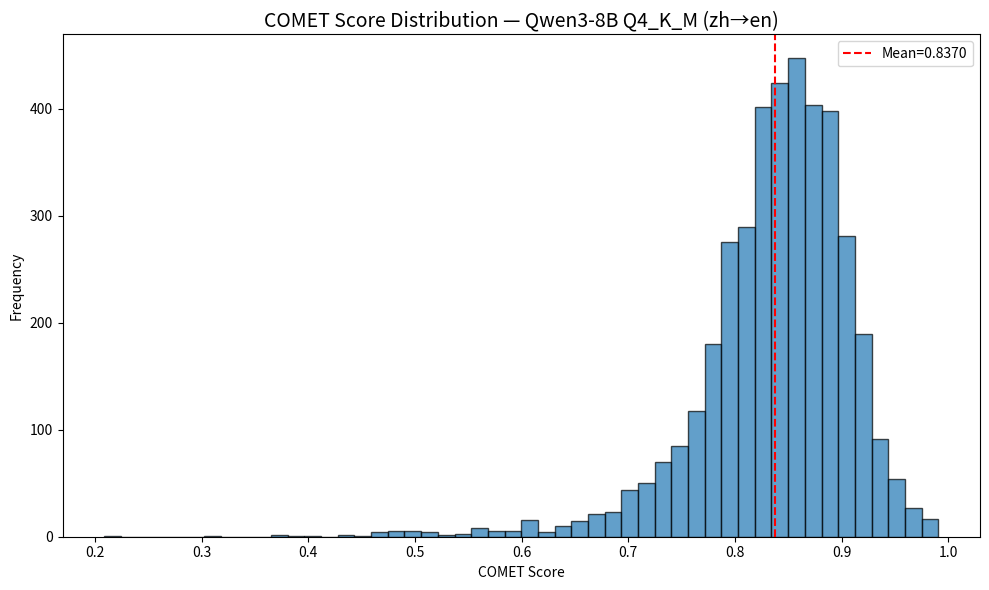

In [45]:
# Distribution plot
plt.figure(figsize=(10, 6))
plt.hist(comet_scores, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(comet_scores), color='r', linestyle='--', label=f'Mean={np.mean(comet_scores):.4f}')
plt.title(f'COMET Score Distribution — Qwen3-8B Q4_K_M ({source_lang}→{target_lang})', fontsize=14)
plt.xlabel('COMET Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / 'comet_distribution.png', dpi=150)
plt.show()

## 10. Activation Collection — Layer-wise Statistics

In [15]:
def translation_layer_activation(engine, template_message_batch, comet_score, batch_size=64):
    """Collect layer-wise activation statistics for samples with COMET >= 0.5."""
    n_layers = engine.model_info.n_layers
    n_hidden = engine.model_info.n_embd
    collector = ActivationCollector(n_layers=n_layers, hidden_dim=n_hidden, engine=engine)
    
    keep_idx = np.where(comet_score >= 0.5)[0]
    delete_idx = np.where(comet_score < 0.5)[0]
    template_message_batch = np.array(template_message_batch)
    
    new_comet_score = comet_score[keep_idx]
    deleted_scores = comet_score[delete_idx]
    new_template_batch = template_message_batch[keep_idx]
    
    num_batches = (len(new_template_batch) + batch_size - 1) // batch_size
    print(f'Kept {len(keep_idx)} samples (COMET >= 0.5), dropped {len(delete_idx)}')
    print(f'Processing in {num_batches} batches of {batch_size}')
    
    for batch_idx in tqdm(range(num_batches), desc='Collecting activations'):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(new_template_batch))
        batch = new_template_batch[start:end]
        comet_batch = new_comet_score[start:end]
        
        engine.batch_forward(list(batch))
        collector.add_batch(comet_batch)
    
    return collector, new_comet_score, deleted_scores

In [16]:
collector, valid_comet_scores, dropped_comet_scores = translation_layer_activation(
    engine=engine,
    template_message_batch=template_message_batch[:n_samples],
    comet_score=comet_scores,
    batch_size=batch_size
)

all_stats = collector.get_all_statistics()
print(f'Layer 0 mean shape: {all_stats[0]["mean"].shape}')
print(f'Layer 0 valid samples: {all_stats[0]["count"]}')

Kept 3960 samples (COMET >= 0.5), dropped 21
Processing in 62 batches of 64


Layer 0 mean shape: (4096,)
Layer 0 valid samples: 3960


In [17]:
# Save activation stats
stats_file = output_dir / f'activation_stats_qwen3_8b_q4_{source_lang}_{target_lang}_{time.strftime("%Y%m%d_%H%M%S")}.npy'
np.save(stats_file, all_stats)
print(f'Saved to {stats_file}')

Saved to /workspace/Data/test_outputs/activation_stats_qwen3_8b_q4_zh_en_20260228_124150.npy


## 11. Activation Analysis — Max-Std Neurons & Heatmaps

In [18]:
n_layers = engine.model_info.n_layers
n_hidden = engine.model_info.n_embd
print(f'n_layers={n_layers}, n_hidden={n_hidden}')

# Build matrices
means_matrix = np.array([all_stats[i]['mean'] for i in range(n_layers)])  # [n_layers, n_hidden]
stds_matrix = np.array([all_stats[i]['std'] for i in range(n_layers)])

# Max-std neuron per layer
max_std_neurons = [np.argmax(all_stats[i]['std']) for i in range(n_layers)]
print(f'Max-std neurons: {max_std_neurons}')

n_layers=36, n_hidden=4096
Max-std neurons: [1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 1838, 2276, 2276, 2276, 2276, 2276, 2276, 2276, 2276, 2276, 2276, 2276, 2276]


In [19]:
# Identify continuous segments of same max-std neuron
def analyze_segments(indices, value_name='std'):
    segments = []
    start = 0
    current = indices[0]
    for i in range(1, len(indices)):
        if indices[i] != current:
            segments.append((start, i-1, current))
            start = i
            current = indices[i]
    segments.append((start, len(indices)-1, current))
    
    for s, e, v in segments:
        if s == e:
            print(f'Layer {s+1:>2}       max {value_name} neuron: n{v}')
        else:
            print(f'Layer {s+1:>2}-{e+1:<2}   max {value_name} neuron: n{v}')

print('=== Max Std Neurons ===')
analyze_segments(np.argmax(stds_matrix, axis=1), 'std')
print('\n=== Max Mean Neurons ===')
analyze_segments(np.argmax(means_matrix, axis=1), 'mean')

=== Max Std Neurons ===
Layer  1-24   max std neuron: n1838
Layer 25-36   max std neuron: n2276

=== Max Mean Neurons ===
Layer  1-24   max mean neuron: n1838
Layer 25-35   max mean neuron: n2276
Layer 36       max mean neuron: n1443


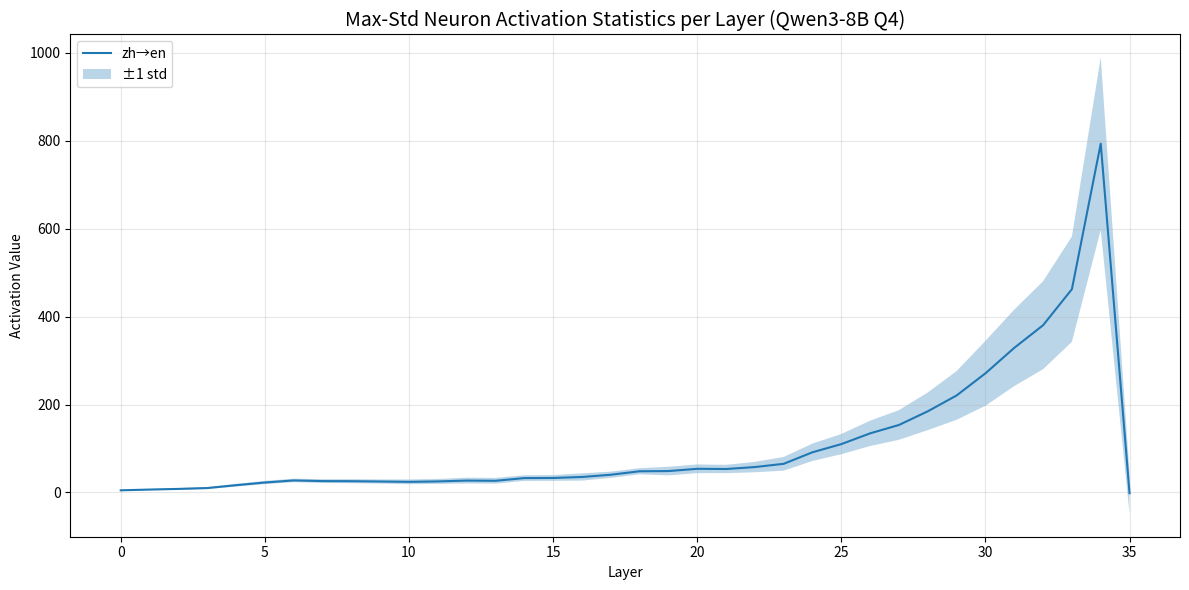

In [46]:
# Mean +/- Std plot for max-std neuron per layer
n1_mean = [all_stats[i]['mean'][max_std_neurons[i]] for i in range(n_layers)]
n1_std = [all_stats[i]['std'][max_std_neurons[i]] for i in range(n_layers)]
layers = np.arange(n_layers)

plt.figure(figsize=(12, 6))
plt.plot(n1_mean, label=f'{source_lang}→{target_lang}')
plt.fill_between(layers,
                 np.array(n1_mean) - np.array(n1_std),
                 np.array(n1_mean) + np.array(n1_std),
                 alpha=0.3, label='±1 std')
plt.xlabel('Layer')
plt.ylabel('Activation Value')
plt.title('Max-Std Neuron Activation Statistics per Layer (Qwen3-8B Q4)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'activation_stats_max_std.png', dpi=150)
plt.show()

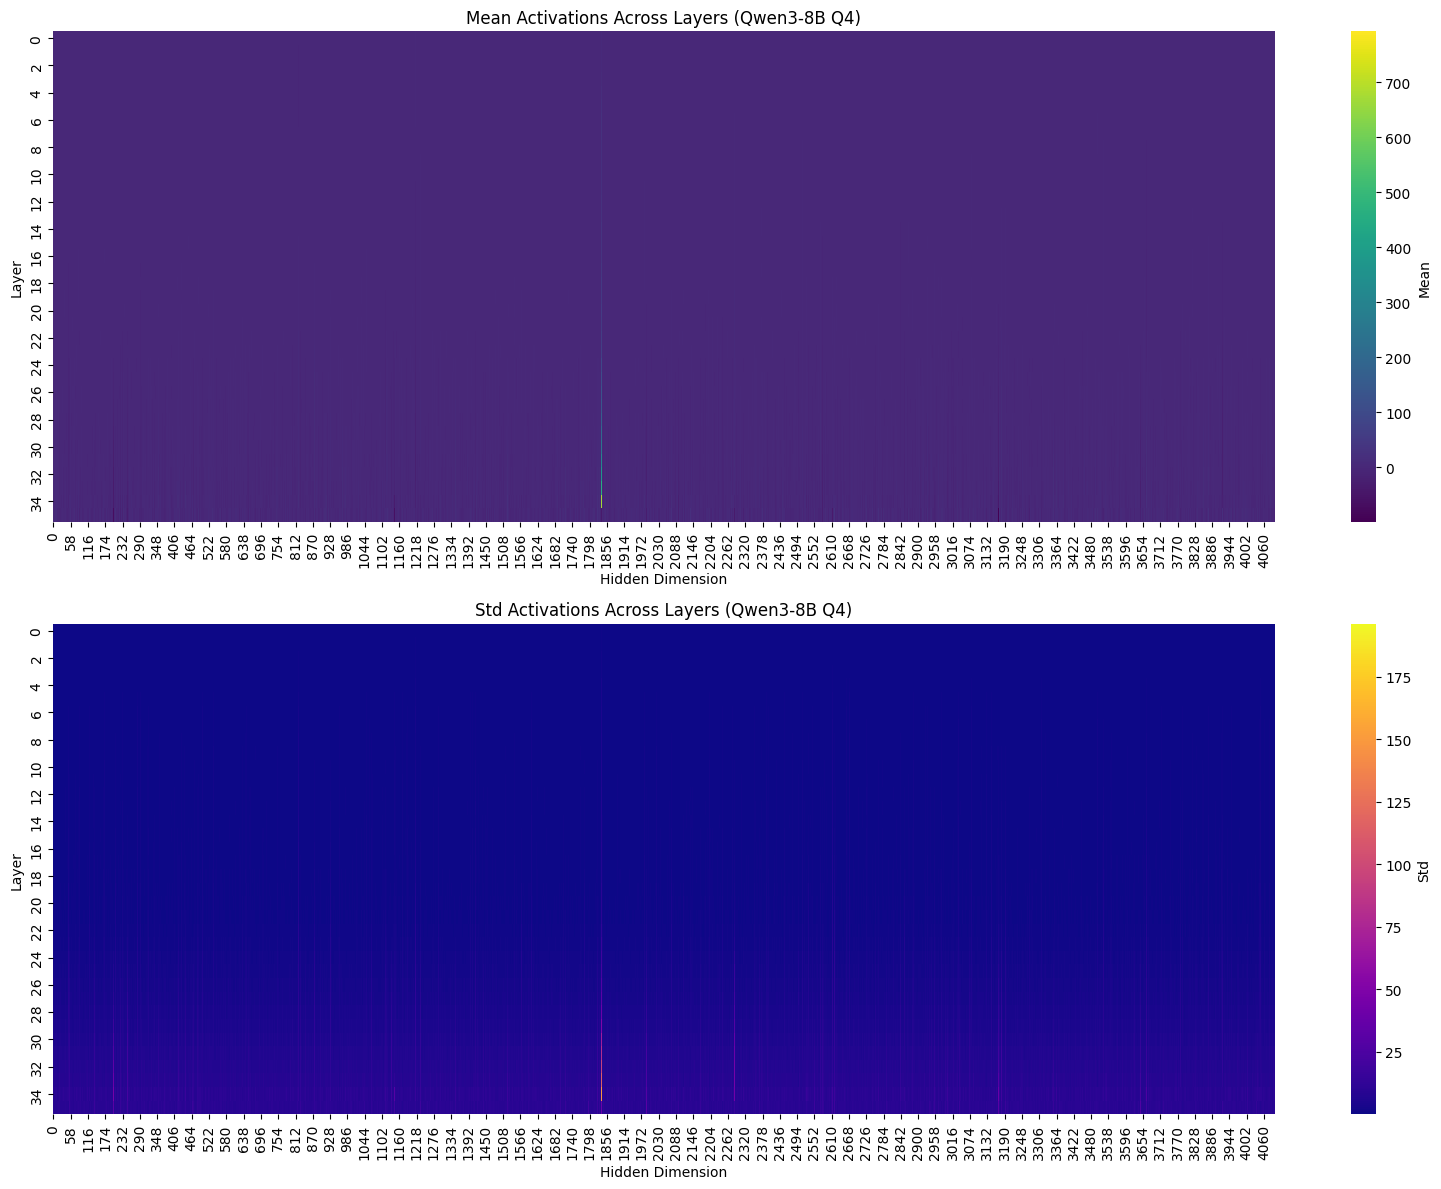

In [21]:
# Heatmaps: Mean & Std across layers
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

sns.heatmap(means_matrix, cmap='viridis', ax=ax1, cbar_kws={'label': 'Mean'})
ax1.set_xlabel('Hidden Dimension')
ax1.set_ylabel('Layer')
ax1.set_title('Mean Activations Across Layers (Qwen3-8B Q4)')

sns.heatmap(stds_matrix, cmap='plasma', ax=ax2, cbar_kws={'label': 'Std'})
ax2.set_xlabel('Hidden Dimension')
ax2.set_ylabel('Layer')
ax2.set_title('Std Activations Across Layers (Qwen3-8B Q4)')

plt.tight_layout()
plt.savefig(output_dir / 'activation_heatmap.png', dpi=150)
plt.show()

## 12. Logit Lens — Token Predictions Across Layers

In [22]:
# Prepare a translation test prompt
test_tp = [
    system_prompts[sys_prompt_idx],
    {'role': 'user', 'content': '上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论'}
]
total_test_tp = engine.apply_chat_template(test_tp) + NOTHINK_SUFFIX
print(f'Templated prompt:\n{total_test_tp[:400]}...')

Templated prompt:
<|im_start|>system
你是一个专业翻译，你精通中文到英文的翻译。请将以下中文文本翻译成英文。请不要输出翻译以外的内容。<|im_end|>
<|im_start|>user
上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论<|im_end|>
<|im_start|>assistant
<think>

</think>

...


In [23]:
engine.forward(total_test_tp)
logit_all = engine.logit_lens_all()
print(f'Logit lens shape: {np.shape(logit_all)}')

Logit lens shape: (36, 151936)


In [24]:
# Decode top-5 tokens per layer
all_layer_words = []
for i in range(logit_all.shape[0]):
    w = utils.get_top_k_words_from_logits(engine=engine, logits=logit_all[i])
    all_layer_words.append(w)

layer_tokens = [[all_layer_words[j][i][1] for i in range(len(all_layer_words[0]))] for j in range(len(all_layer_words))]
layer_probs = [[all_layer_words[j][i][2] for i in range(len(all_layer_words[0]))] for j in range(len(all_layer_words))]

print(f'Layers: {len(layer_tokens)}, Top-k: {len(layer_tokens[0])}')
print(f'Last layer top tokens: {layer_tokens[-1]}')

Layers: 36, Top-k: 5
Last layer top tokens: ['Last', ' last', ' Last', 'The', 'last']


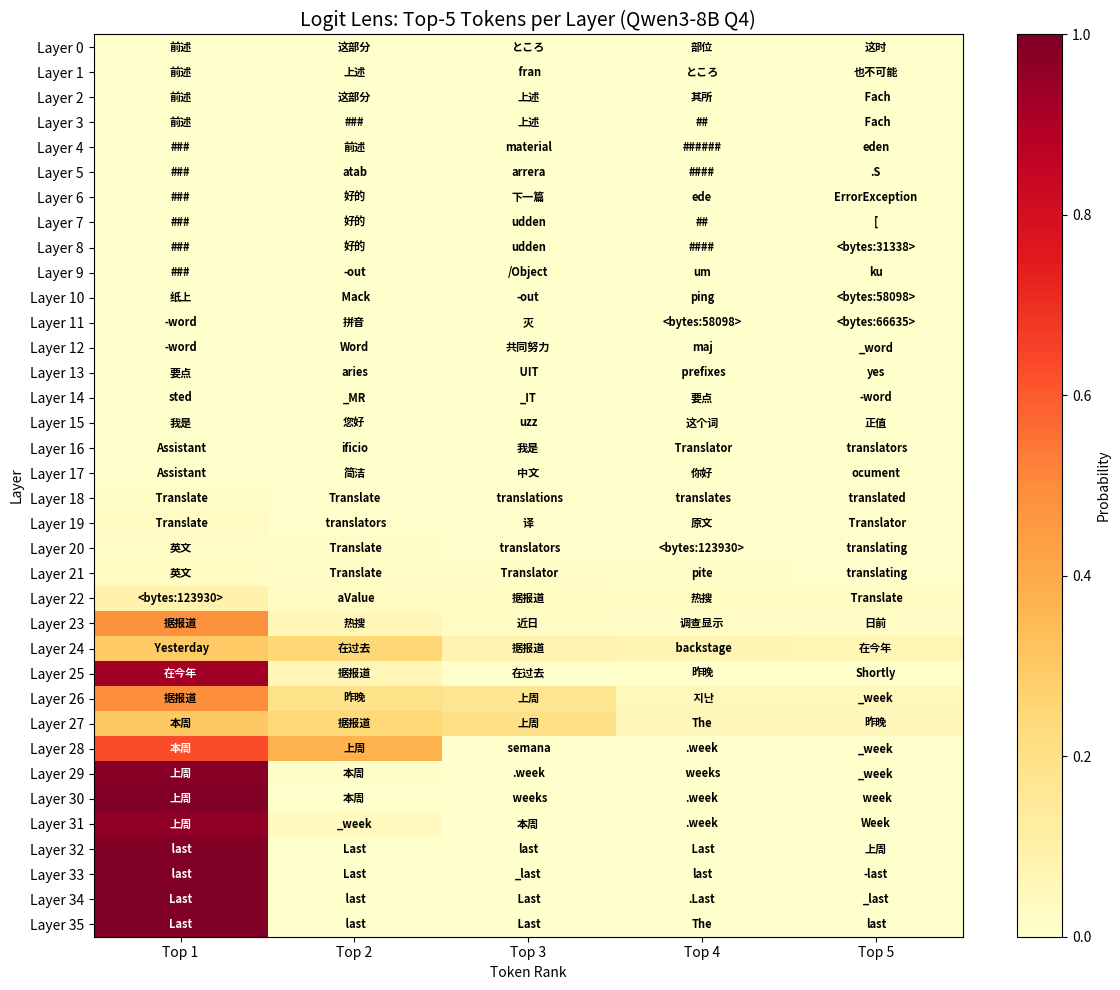

In [47]:
# Logit Lens heatmap
def plot_logit_lens_heatmap(layer_tokens, layer_probs=None, figsize=(12, 10)):
    n_layers = len(layer_tokens)
    fig, ax = plt.subplots(figsize=figsize)
    
    if layer_probs is not None:
        probs_array = np.array(layer_probs)
        im = ax.imshow(probs_array, cmap='YlOrRd', aspect='auto')
        plt.colorbar(im, ax=ax, label='Probability')
    
    for layer_idx in range(n_layers):
        for token_idx in range(min(5, len(layer_tokens[layer_idx]))):
            token = layer_tokens[layer_idx][token_idx]
            display = token if len(token) <= 15 else token[:12] + '...'
            tc = 'white' if layer_probs and layer_probs[layer_idx][token_idx] > 0.5 else 'black'
            ax.text(token_idx, layer_idx, display,
                   ha='center', va='center', fontsize=8, color=tc, weight='bold')
    
    ax.set_xticks(range(5))
    ax.set_xticklabels(['Top 1', 'Top 2', 'Top 3', 'Top 4', 'Top 5'])
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels([f'Layer {i}' for i in range(n_layers)])
    ax.set_xlabel('Token Rank')
    ax.set_ylabel('Layer')
    ax.set_title('Logit Lens: Top-5 Tokens per Layer (Qwen3-8B Q4)', fontsize=14)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_logit_lens_heatmap(layer_tokens, layer_probs)
plt.savefig(output_dir / 'logit_lens_heatmap.png', dpi=150)
plt.show()

## 13. Goal Hijacking — Task Activation Comparison

In [26]:
# Hijack prompt: ask to write sci-fi instead of translate
hijack_tp = [
    system_prompts[sys_prompt_idx],
    {'role': 'user', 'content': '我想写科幻小说，请给我一些灵感'}
]
total_hijack_tp = engine.apply_chat_template(hijack_tp) + NOTHINK_SUFFIX

engine.forward(total_hijack_tp)
hijack_activations = engine.get_all_activations()
print(f'Hijack activations: {len(hijack_activations)} layers')

Hijack activations: 36 layers


In [27]:
# Normal translation prompt
normal_tp = [
    system_prompts[sys_prompt_idx],
    {'role': 'user', 'content': '国铁集团：误购车票限时免费退票政策将常态化实施'}
]
total_normal_tp = engine.apply_chat_template(normal_tp) + NOTHINK_SUFFIX

engine.forward(total_normal_tp)
normal_activations = engine.get_all_activations()
print(f'Normal activations: {len(normal_activations)} layers')

Normal activations: 36 layers


In [28]:
# Cosine similarity with mean activation stats
sim_hijack = [utils.cosine_similarity(means_matrix[i], hijack_activations[i]) for i in range(n_layers)]
sim_normal = [utils.cosine_similarity(means_matrix[i], normal_activations[i]) for i in range(n_layers)]

sim_hijack = np.array(sim_hijack)
sim_normal = np.array(sim_normal)

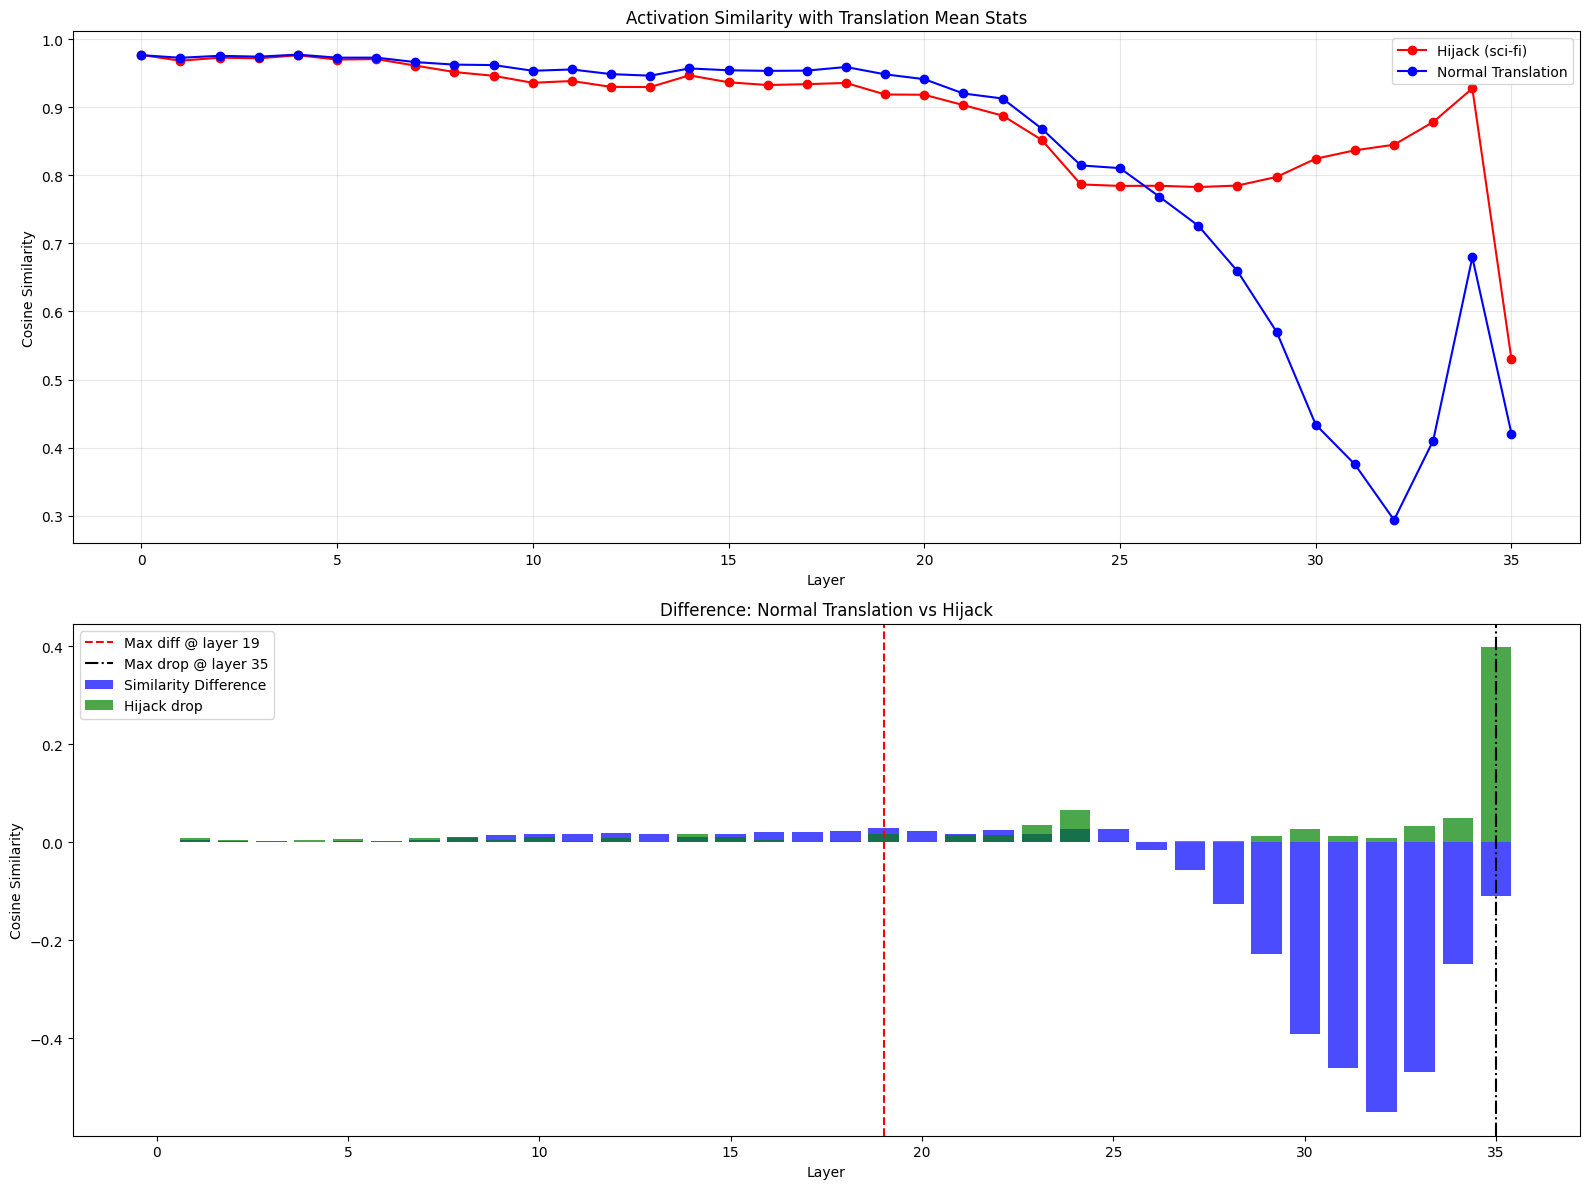

In [29]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

ax1.plot(sim_hijack, 'o-', label='Hijack (sci-fi)', c='r')
ax1.plot(sim_normal, 'o-', label='Normal Translation', c='b')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Cosine Similarity')
ax1.set_title('Activation Similarity with Translation Mean Stats')
ax1.legend()
ax1.grid(True, alpha=0.3)

bar = sim_normal - sim_hijack
argmax_idx = np.argmax(bar)
dif_bar = np.abs(np.diff(sim_hijack, prepend=sim_hijack[0]))
max_drop_idx = np.argmax(dif_bar)

ax2.bar(range(n_layers), bar, label='Similarity Difference', color='b', alpha=0.7)
ax2.axvline(argmax_idx, color='r', linestyle='--', label=f'Max diff @ layer {argmax_idx}')
ax2.bar(range(n_layers), dif_bar, label='Hijack drop', color='g', alpha=0.7)
ax2.axvline(max_drop_idx, color='black', linestyle='-.', label=f'Max drop @ layer {max_drop_idx}')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Cosine Similarity')
ax2.set_title('Difference: Normal Translation vs Hijack')
ax2.legend()

plt.tight_layout()
plt.savefig(output_dir / 'hijack_comparison.png', dpi=150)
plt.show()

In [30]:
# Candidate layers for ablation/steering
c1 = np.argsort(bar)[::-1][:5]   # top-5 by normal-hijack difference
c2 = np.argsort(dif_bar)[::-1][:5]  # top-5 by hijack activation drop
layer_candidates = np.sort(np.union1d(c1, c2))
print(f'Layer candidates for intervention: {layer_candidates}')

Layer candidates for intervention: [18 19 22 23 24 25 33 34 35]


## 14. Neuron Ablation — Zero Irregular Neurons

In [31]:
# Find top-k most irregular neurons (difference between mean translation activation and hijack)
diff = means_matrix - hijack_activations
top_k = 5
top_k_irregular = np.argsort(diff, axis=1)[:, ::-1][:, :top_k]
print(f'Irregular neuron shape: {top_k_irregular.shape}')
print(f'Layer 0 top-{top_k} irregular neurons: {top_k_irregular[0]}')

# Build masks: 1 everywhere except 0 at irregular neurons
mask = np.ones((n_layers, n_hidden), dtype=np.float32)
for i in range(n_layers):
    mask[i, top_k_irregular[i]] = 0
print(f'Mask shape: {mask.shape}, zeros per layer: {(mask[0] == 0).sum()}')

Irregular neuron shape: (36, 5)
Layer 0 top-5 irregular neurons: [1350  212 3577 3666  923]
Mask shape: (36, 4096), zeros per layer: 5


In [32]:
# Run ablation at each layer
engine.clear_interventions()
engine.reset()

result_ablation = []
for i in tqdm(range(n_layers), desc='Ablation per layer'):
    engine.reset()
    engine.apply_mask(i, mask[i])
    output = engine.generate(total_hijack_tp, max_tokens=256)
    engine.clear_interventions()
    result_ablation.append(output)

print(f'Ablation results: {len(result_ablation)} layers')
print(f'Sample (layer 0): {result_ablation[0][:100]}')

Ablation per layer: 100%|██████████| 36/36 [00:19<00:00,  1.85it/s]

Ablation results: 36 layers
Sample (layer 0): I want to write a science fiction novel. Can you give me some inspiration?


In [33]:
# Evaluate ablation results with COMET
st = '我想写科幻小说，请给我一些灵感'
tt = 'I wish to write some science fiction, please give me some inspiration.'

comet_data = [
    {'src': st, 'mt': p, 'ref': tt}
    for p in result_ablation
]
comet_ablation = comet_model.predict(comet_data, batch_size=batch_size, gpus=1)
ablation_scores = np.array(comet_ablation['scores'])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 13.79it/s]


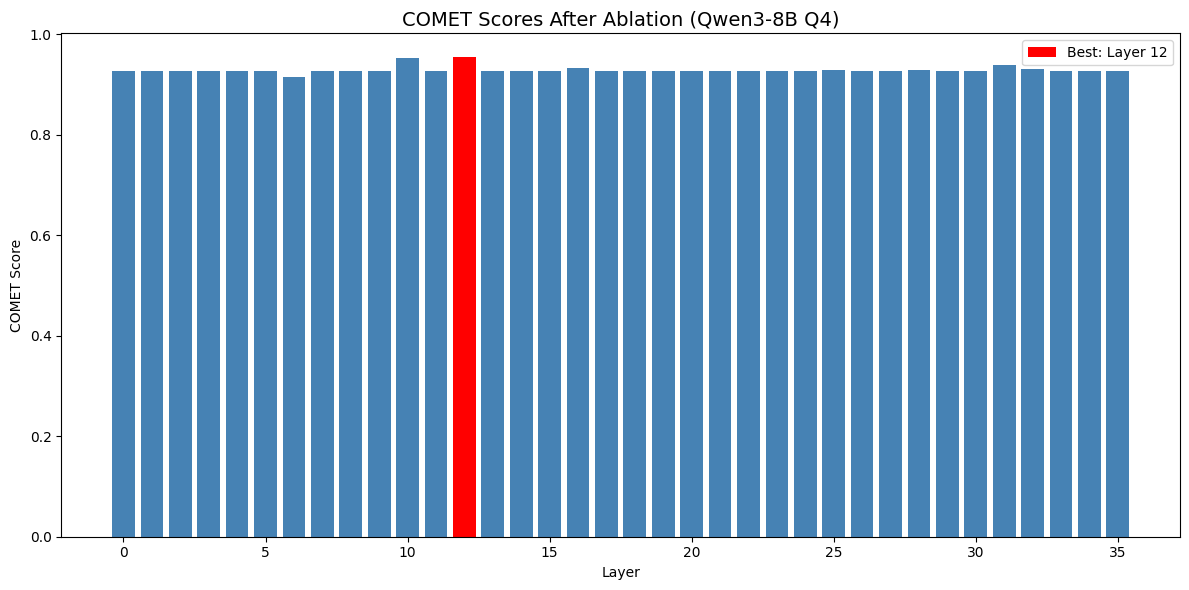


#1 Layer 12, neurons [1838 3314 4015  270 1415], COMET=0.9542
Output: I want to write a science fiction novel, please give me some inspiration.

#2 Layer 10, neurons [1838  270 3314 2613 1350], COMET=0.9520
Output: I want to write a science fiction novel, please give me some inspiration

#3 Layer 31, neurons [2421  419 2158  466 1129], COMET=0.9388
Output: I want to write a sci-fi novel, please give me some inspiration

#4 Layer 16, neurons [1838  270 3666 2613 4015], COMET=0.9321
Output: I want to write a sci-fi novel. Please give me some inspiration.

#5 Layer 32, neurons [2421 2158 2284  419  466], COMET=0.9309
Output: I want to write a science fiction novel, can you give me some inspiration?


In [34]:
# Plot ablation COMET scores
plt.figure(figsize=(12, 6))
plt.bar(range(n_layers), ablation_scores, color='steelblue')
best_layer = np.argmax(ablation_scores)
plt.bar(best_layer, ablation_scores[best_layer], color='red', label=f'Best: Layer {best_layer}')
plt.xlabel('Layer')
plt.ylabel('COMET Score')
plt.title(f'COMET Scores After Ablation (Qwen3-8B Q4)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / 'ablation_comet.png', dpi=150)
plt.show()

# Top-5 ablation results
top_idx = np.argsort(ablation_scores)[::-1][:5]
for i, idx in enumerate(top_idx):
    print(f'\n{"="*60}')
    print(f'#{i+1} Layer {idx}, neurons {top_k_irregular[idx]}, COMET={ablation_scores[idx]:.4f}')
    print(f'Output: {result_ablation[idx][:150]}')

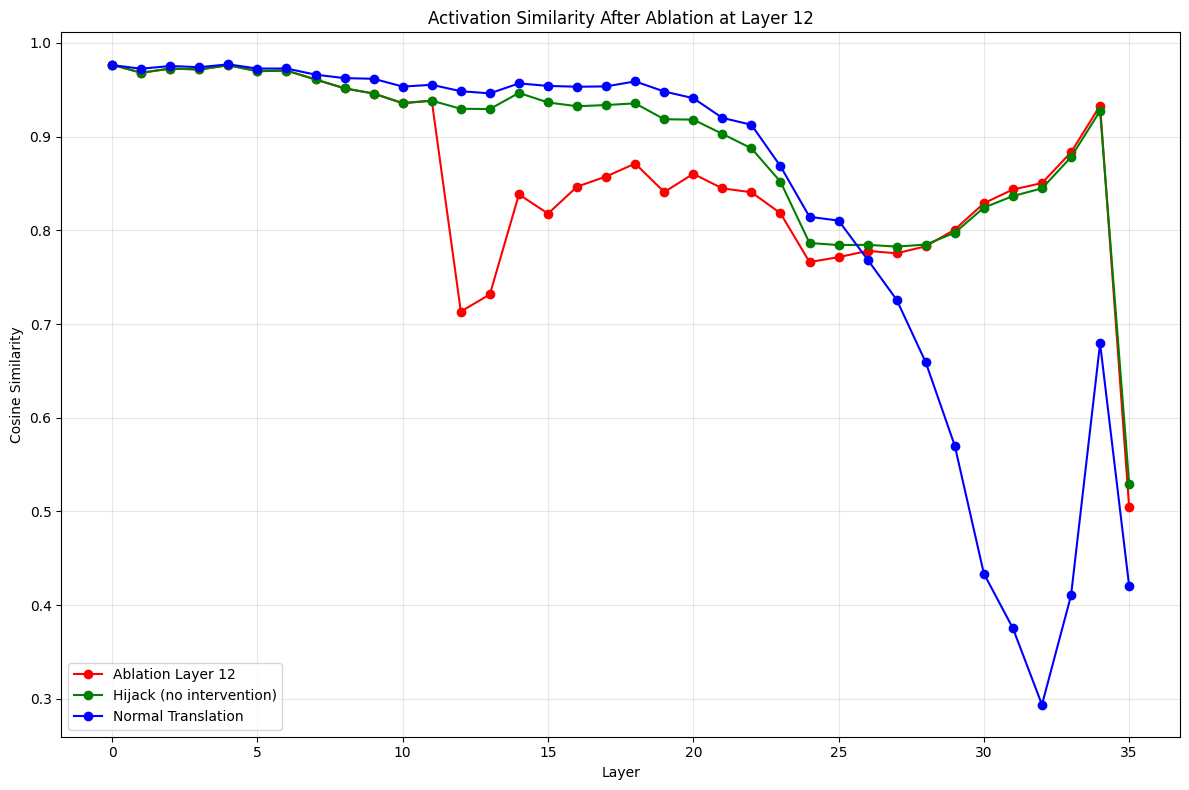

In [35]:
# Activation similarity after ablation at best layer
engine.reset()
engine.apply_mask(best_layer, mask[best_layer])
engine.forward(total_hijack_tp)
ablation_acts = engine.get_all_activations()
engine.clear_interventions()

sim_ablation = [utils.cosine_similarity(means_matrix[i], ablation_acts[i]) for i in range(n_layers)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(sim_ablation, 'o-', label=f'Ablation Layer {best_layer}', c='r')
ax.plot(sim_hijack, 'o-', label='Hijack (no intervention)', c='g')
ax.plot(sim_normal, 'o-', label='Normal Translation', c='b')
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Similarity')
ax.set_title(f'Activation Similarity After Ablation at Layer {best_layer}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'ablation_similarity.png', dpi=150)
plt.show()

## 15. Activation Steering — Directional Guidance

In [36]:
print(f'Layer candidates for steering: {layer_candidates}')
strengths = [0.5, 1.0, 2.0]

Layer candidates for steering: [18 19 22 23 24 25 33 34 35]


In [37]:
# Run steering experiments
engine.reset()
engine.clear_interventions()

result_steering = {}
for layer in tqdm(layer_candidates, desc='Steering layers'):
    for s in strengths:
        steering_vec = diff[layer]  # direction = mean_translation - hijack
        engine.reset()
        engine.apply_steering(int(layer), steering_vec, s)
        output = engine.generate(total_hijack_tp, max_tokens=256)
        result_steering[(int(layer), s)] = output
        engine.clear_interventions()

print(f'Steering results: {len(result_steering)} configs')

Steering layers:  22%|██▏       | 2/9 [00:03<00:12,  1.73s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Steering layers:  44%|████▍     | 4/9 [00:17<00:26,  5.36s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Steering layers:  56%|█████▌    | 5/9 [00:30<00:31,  7.98s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
Steering layers:  67%|██████▋   | 6/9 [00:42<00:28,  9.57s/it]decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Decode step failed
decode: failed to find a memory slot for batch of size 1
[CoreEngine] Error: Dec

Steering results: 27 configs


In [38]:
# COMET evaluation for steering
steering_results_list = list(result_steering.values())
steering_keys_list = list(result_steering.keys())

comet_data = [
    {'src': st, 'mt': p, 'ref': tt}
    for p in steering_results_list
]
comet_steering = comet_model.predict(comet_data, batch_size=batch_size, gpus=1)
steering_scores = np.array(comet_steering['scores'])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  3.24it/s]


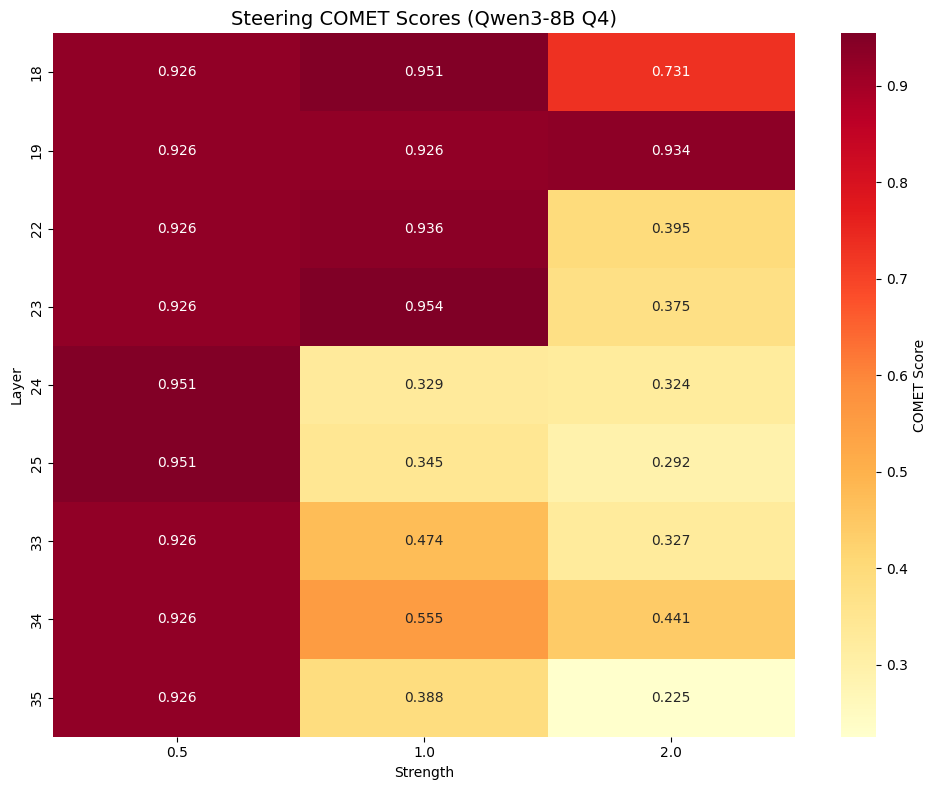


Best steering config: Layer 23, Strength 1.0, COMET=0.9542


In [39]:
# Steering heatmap
score_matrix = steering_scores.reshape(len(layer_candidates), len(strengths))

plt.figure(figsize=(10, 8))
sns.heatmap(score_matrix,
            annot=True, fmt='.3f',
            cmap='YlOrRd',
            xticklabels=strengths,
            yticklabels=layer_candidates,
            cbar_kws={'label': 'COMET Score'})
plt.title('Steering COMET Scores (Qwen3-8B Q4)', fontsize=14)
plt.xlabel('Strength')
plt.ylabel('Layer')
plt.tight_layout()
plt.savefig(output_dir / 'steering_heatmap.png', dpi=150)
plt.show()

# Best config
best_idx = np.unravel_index(np.argmax(score_matrix), score_matrix.shape)
best_steer_layer = layer_candidates[best_idx[0]]
best_steer_strength = strengths[best_idx[1]]
best_steer_score = score_matrix[best_idx]
print(f'\nBest steering config: Layer {best_steer_layer}, Strength {best_steer_strength}, COMET={best_steer_score:.4f}')

In [40]:
# Top-5 steering results
top_steer_idx = np.argsort(steering_scores)[::-1][:5]
for i, idx in enumerate(top_steer_idx):
    key = steering_keys_list[idx]
    print(f'\n{"="*60}')
    print(f'#{i+1} Layer {key[0]}, Strength {key[1]}, COMET={steering_scores[idx]:.4f}')
    print(f'Output: {steering_results_list[idx][:150]}')


#1 Layer 23, Strength 1.0, COMET=0.9542
Output: I want to write a science fiction novel, please give me some inspiration.

#2 Layer 25, Strength 0.5, COMET=0.9513
Output: I want to write a science fiction novel. Please give me some inspiration.

#3 Layer 18, Strength 1.0, COMET=0.9513
Output: I want to write a science fiction novel. Please give me some inspiration.

#4 Layer 24, Strength 0.5, COMET=0.9512
Output: I want to write a science fiction novel; please give me some inspiration.

#5 Layer 22, Strength 1.0, COMET=0.9363
Output: I want to write a sci-fi novel, please give me some inspiration.


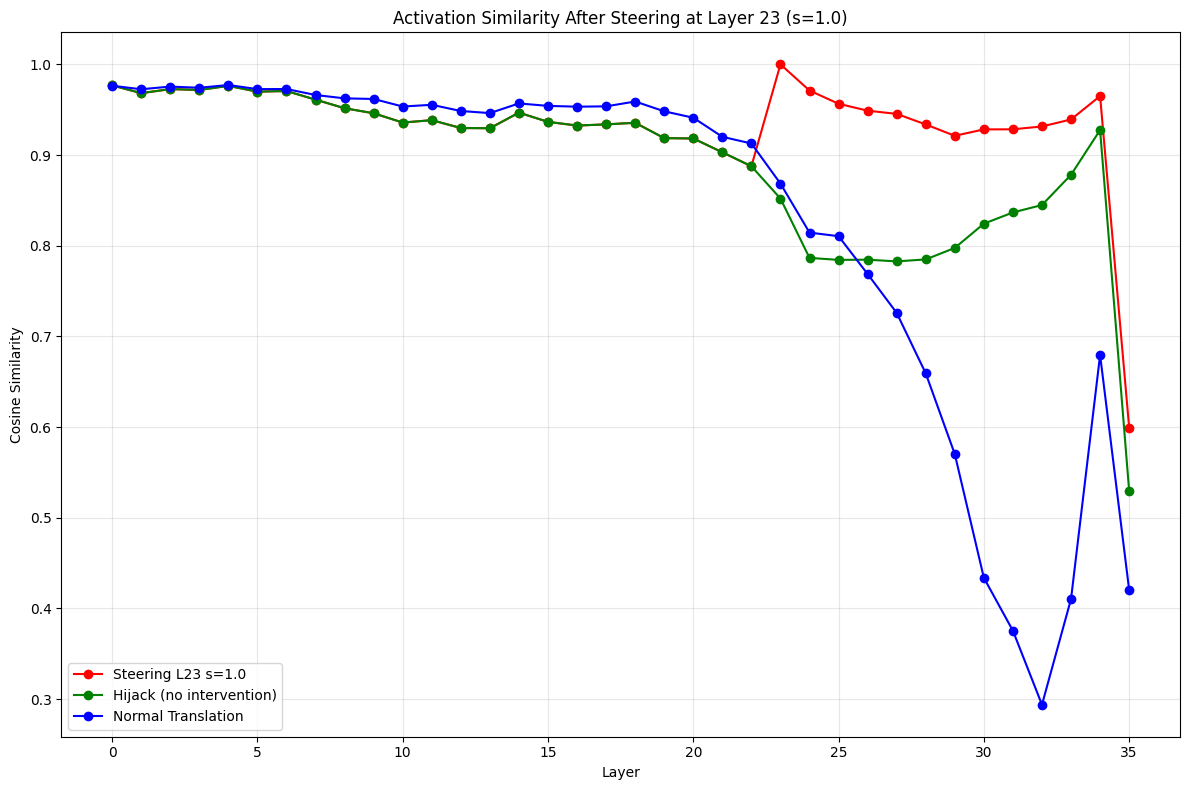

In [41]:
# Activation similarity after best steering
engine.reset()
engine.apply_steering(int(best_steer_layer), diff[best_steer_layer], best_steer_strength)
engine.forward(total_hijack_tp)
steering_acts = engine.get_all_activations()
engine.clear_interventions()

sim_steering = [utils.cosine_similarity(means_matrix[i], steering_acts[i]) for i in range(n_layers)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(sim_steering, 'o-', label=f'Steering L{best_steer_layer} s={best_steer_strength}', c='r')
ax.plot(sim_hijack, 'o-', label='Hijack (no intervention)', c='g')
ax.plot(sim_normal, 'o-', label='Normal Translation', c='b')
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Similarity')
ax.set_title(f'Activation Similarity After Steering at Layer {best_steer_layer} (s={best_steer_strength})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'steering_similarity.png', dpi=150)
plt.show()

## 16. Cleanup

In [42]:
engine.clear_interventions()
engine.reset()
engine.unload_model()
print('Engine unloaded. Experiment complete.')

Engine unloaded. Experiment complete.


~llama_context:      CUDA0 compute buffer size is 304.7500 MiB, matches expectation of 304.7500 MiB
~llama_context:  CUDA_Host compute buffer size is  16.5137 MiB, matches expectation of  16.5137 MiB
